# Task 5: (Model Evaluation & Selection)
**Student Dropout and Academic Success Dataset**
This notebook covers:
1. Retrain baseline models
2. Calculate detailed metrics (accuracy, precision, recall, F1)
3. Plot ROC curves and calculate AUC
4. Improve models via cross-validation
5. Validation curve analysis (overfitting/underfitting)
6. Comprehensive discussion

In [1]:
import sys
import os
import json

#  / Add project root to path
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.prediction import train_model, get_model
from src.evaluation import (
    calculate_metrics,
    cross_validate_model,
    plot_validation_curve,
    plot_learning_curve,
    metrics_comparison_table,
)

#  / Set plotting style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

PLOT_DIR = os.path.join(project_root, "data", "plots")
os.makedirs(PLOT_DIR, exist_ok=True)


In [2]:
#  / Load engineered feature data
data_dir = os.path.join(project_root, "data")

X_train = pd.read_csv(os.path.join(data_dir, "features_engineered_train.csv"))
y_train = pd.read_csv(os.path.join(data_dir, "targets_engineered_train.csv")).iloc[:, 0]
X_val = pd.read_csv(os.path.join(data_dir, "features_engineered_val.csv"))
y_val = pd.read_csv(os.path.join(data_dir, "targets_engineered_val.csv")).iloc[:, 0]
X_test = pd.read_csv(os.path.join(data_dir, "features_engineered_test.csv"))
y_test = pd.read_csv(os.path.join(data_dir, "targets_engineered_test.csv")).iloc[:, 0]

#  engineered top-40  / Verify engineered top-40 feature space
for name, X in [("train", X_train), ("val", X_val), ("test", X_test)]:
    assert X.shape[1] == 40, f"{name} has {X.shape[1]} features, expected 40"

#  train+val  / Merge train+val for cross-validation
X_trainval = pd.concat([X_train, X_val], ignore_index=True)
y_trainval = pd.concat([y_train, y_val], ignore_index=True)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"Train+Val (for CV): {X_trainval.shape}")


Train: (3096, 40), Val: (664, 40), Test: (664, 40)
Train+Val (for CV): (3760, 40)


## 1. Retrain Models & Calculate Detailed Metrics
Retrain with model configs from NB04, then calculate full precision / recall / F1 metrics.

In [3]:
#  NB04 baseline  / Retrain NB04 baseline models
models = {
    "Decision Tree": train_model(X_train.values, y_train.values, "dt"),
    "Logistic Regression": train_model(X_train.values, y_train.values, "lr"),
    "SVM (RBF)": train_model(X_train.values, y_train.values, "svm"),
}

#  / Calculate detailed metrics per model on test set
metrics_results = {}
for name, model in models.items():
    y_pred = model.predict(X_test.values)
    metrics = calculate_metrics(y_test.values, y_pred)
    metrics_results[name] = metrics
    print(f"\n{name}:")
    for k, v in metrics.items():
        print(f"  {k}: {v:.4f}")

#  baseline metrics / Save baseline metrics
metrics_df = metrics_comparison_table(metrics_results).rename(columns={"Model": "model"})
metrics_df.insert(1, "set", "test")
metrics_path = os.path.join(data_dir, "model_evaluation_baseline_metrics.csv")
metrics_df.to_csv(metrics_path, index=False)

print("\nDetailed metrics comparison: Detailed Metrics Comparison:")
print(metrics_df.round(4).to_string(index=False))
print(f"\nSaved baseline metrics to {metrics_path}")



Decision Tree:
  accuracy: 0.7123
  precision_macro: 0.6859
  precision_weighted: 0.7579
  recall_macro: 0.6908
  recall_weighted: 0.7123
  f1_macro: 0.6752
  f1_weighted: 0.7263

Logistic Regression:
  accuracy: 0.7410
  precision_macro: 0.7159
  precision_weighted: 0.7854
  recall_macro: 0.7237
  recall_weighted: 0.7410
  f1_macro: 0.7076
  f1_weighted: 0.7550



SVM (RBF):
  accuracy: 0.7319
  precision_macro: 0.7054
  precision_weighted: 0.7740
  recall_macro: 0.7096
  recall_weighted: 0.7319
  f1_macro: 0.6955
  f1_weighted: 0.7448

Detailed metrics comparison: Detailed Metrics Comparison:
              model  set  accuracy  precision_macro  precision_weighted  recall_macro  recall_weighted  f1_macro  f1_weighted
      Decision Tree test    0.7123           0.6859              0.7579        0.6908           0.7123    0.6752       0.7263
Logistic Regression test    0.7410           0.7159              0.7854        0.7237           0.7410    0.7076       0.7550
          SVM (RBF) test    0.7319           0.7054              0.7740        0.7096           0.7319    0.6955       0.7448

Saved baseline metrics to E:\Project\2011machine_learning\data\model_evaluation_baseline_metrics.csv


## 2. ROC Curves & AUC
Plot ROC curves using One-vs-Rest strategy for the 3-class problem. Each curve corresponds to one class.

Saved: data/plots/05_roc_curves_combined.png


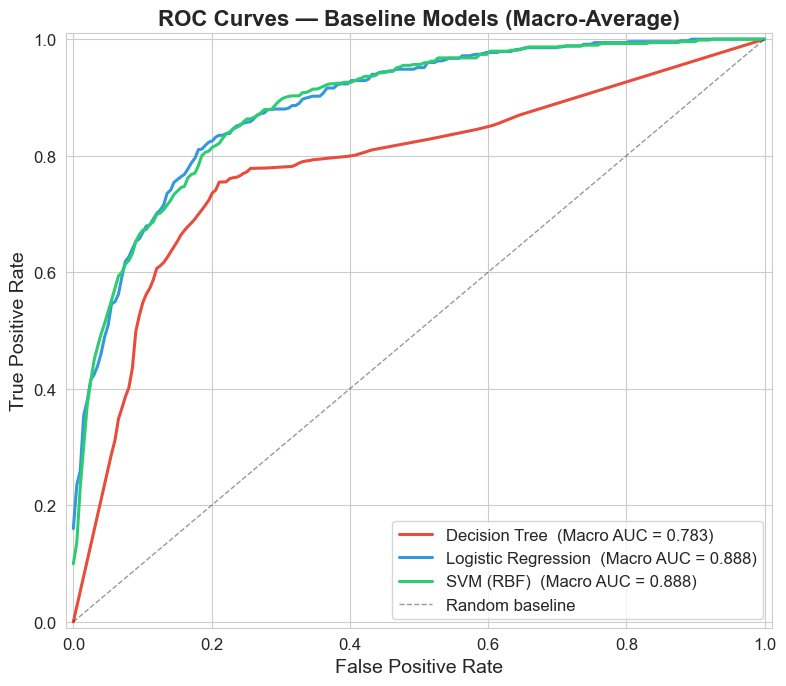

  Decision Tree Macro: 0.7826
  Logistic Regression Macro: 0.8880
  SVM (RBF) Macro: 0.8875

Saved AUC values to E:\Project\2011machine_learning\data\model_evaluation_auc.csv


In [4]:
#  ROC    macro-average  / Combined ROC: macro-average on one figure
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

classes = sorted(y_test.unique())
y_test_bin = label_binarize(y_test.values, classes=classes)

fig, ax = plt.subplots(figsize=(8, 7))
colors_roc = {"Decision Tree": "#e74c3c", "Logistic Regression": "#3498db", "SVM (RBF)": "#2ecc71"}

auc_dict = {}
for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test.values)
    else:
        y_score = model.decision_function(X_test.values)

    mean_fpr = np.linspace(0, 1, 200)
    tprs = []
    for i in range(len(classes)):
        fpr_i, tpr_i, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        tprs.append(np.interp(mean_fpr, fpr_i, tpr_i))
    mean_tpr = np.mean(tprs, axis=0)
    macro_auc = auc(mean_fpr, mean_tpr)
    auc_dict[name] = {"Macro": macro_auc}

    ax.plot(mean_fpr, mean_tpr, color=colors_roc[name], linewidth=2.2,
            label=f"{name}  (Macro AUC = {macro_auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", alpha=0.4, linewidth=1, label="Random baseline")
ax.set_xlabel("False Positive Rate", fontsize=14)
ax.set_ylabel("True Positive Rate", fontsize=14)
ax.set_title("ROC Curves — Baseline Models (Macro-Average)", fontsize=16, fontweight="bold")
ax.legend(fontsize=12, loc="lower right")
ax.tick_params(labelsize=12)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "05_roc_curves_combined.png"), dpi=200, bbox_inches="tight",
            facecolor="white")
print("Saved: data/plots/05_roc_curves_combined.png")
plt.show()

#  AUC / Save AUC
auc_rows = []
for model_name, aucs in auc_dict.items():
    for cls, val in aucs.items():
        auc_rows.append({"model": model_name, "class": cls, "auc": float(val)})
        print(f"  {model_name} {cls}: {val:.4f}")
auc_df = pd.DataFrame(auc_rows)
auc_path = os.path.join(data_dir, "model_evaluation_auc.csv")
auc_df.to_csv(auc_path, index=False)
print(f"\nSaved AUC values to {auc_path}")

## 3. Cross-Validation
Evaluate generalization via 5-fold CV on the combined train+val set.

Decision Tree: F1(macro) = 0.6511 ± 0.0144
  Per-fold: ['0.6734', '0.6424', '0.6628', '0.6366', '0.6405']


Logistic Regression: F1(macro) = 0.7029 ± 0.0064
  Per-fold: ['0.6914', '0.7067', '0.7066', '0.7091', '0.7010']


SVM (RBF): F1(macro) = 0.6955 ± 0.0063
  Per-fold: ['0.6998', '0.6870', '0.6987', '0.6889', '0.7030']
Saved Plot saved to data/plots/05_cv_results.png
Saved CV results to E:\Project\2011machine_learning\data\model_evaluation_cv.csv


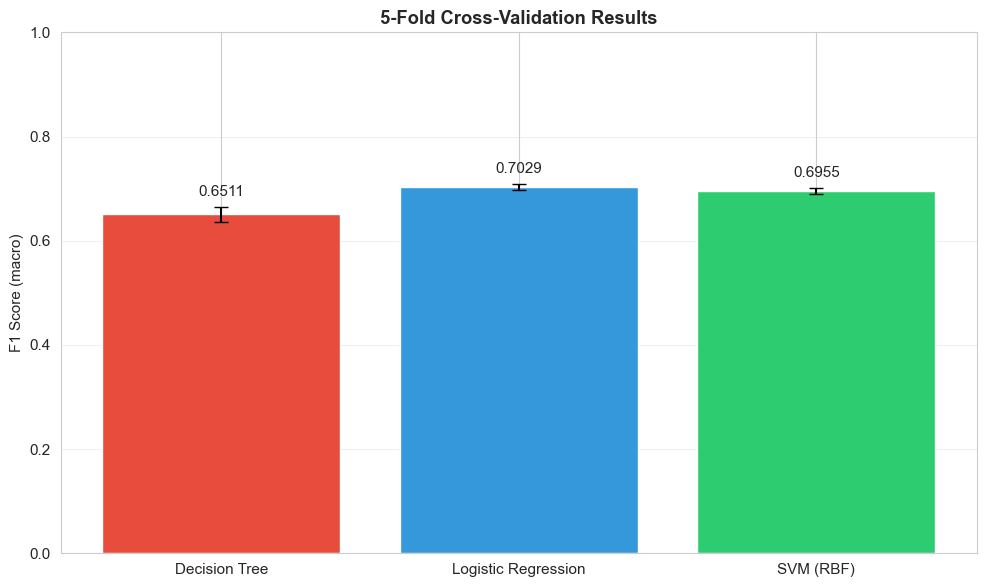

In [5]:
# 5-fold  / 5-fold cross-validation
cv_results = {}
model_keys = {
    "Decision Tree": "dt",
    "Logistic Regression": "lr",
    "SVM (RBF)": "svm",
}
for name, model_type in model_keys.items():
    fresh_model = get_model(model_type)
    cv_res = cross_validate_model(fresh_model, X_trainval.values, y_trainval.values, cv=5)
    cv_results[name] = cv_res
    print(f"{name}: F1(macro) = {cv_res['mean']:.4f} ± {cv_res['std']:.4f}")
    print(f"  Per-fold: {[f'{s:.4f}' for s in cv_res['scores']]}")

#  CV  / Save CV results
cv_rows = []
for name, cv_res in cv_results.items():
    row = {
        "model": name,
        "cv": int(cv_res["cv"]),
        "scoring": cv_res["scoring"],
        "mean_f1_macro": float(cv_res["mean"]),
        "std_f1_macro": float(cv_res["std"]),
    }
    for idx, score in enumerate(cv_res["scores"], start=1):
        row[f"fold_{idx}"] = float(score)
    cv_rows.append(row)
cv_df = pd.DataFrame(cv_rows)
cv_path = os.path.join(data_dir, "model_evaluation_cv.csv")
cv_df.to_csv(cv_path, index=False)

#  CV  / Visualize CV results
fig, ax = plt.subplots(figsize=(10, 6))
models_list = list(cv_results.keys())
means = [cv_results[m]["mean"] for m in models_list]
stds = [cv_results[m]["std"] for m in models_list]
colors = ["#e74c3c", "#3498db", "#2ecc71"]

bars = ax.bar(models_list, means, yerr=stds, color=colors, edgecolor="white", capsize=5)
ax.set_ylabel("F1 Score (macro)")
ax.set_title("5-Fold Cross-Validation Results", fontweight="bold")
ax.set_ylim(0, 1)
for bar, m, s in zip(bars, means, stds):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + s + 0.02,
        f"{m:.4f}",
        ha="center",
        fontsize=11,
    )
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "05_cv_results.png"), dpi=150, bbox_inches="tight")
print(f"Saved Plot saved to data/plots/05_cv_results.png")
print(f"Saved CV results to {cv_path}")
plt.show()


## 4. Validation Curve Analysis
Use validation curves to diagnose overfitting or underfitting.

Saved: data/plots/05_valcurve_dt_depth_large.png


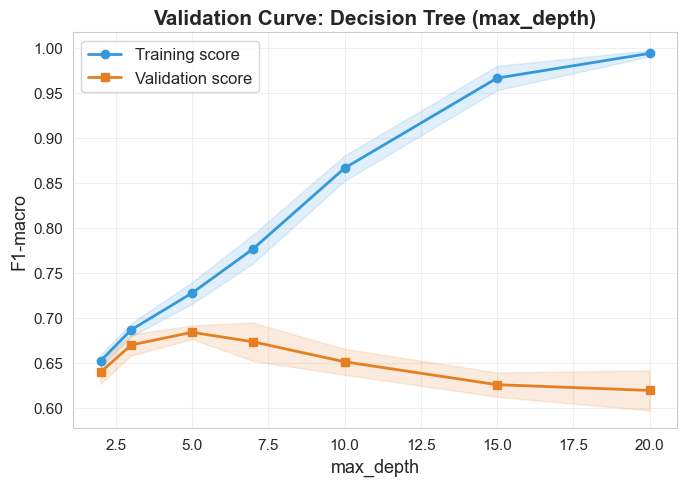

In [6]:
# Decision Tree: max_depth    / DT max_depth validation curve  large figure
from sklearn.model_selection import validation_curve as sklearn_valcurve

dt_model = get_model("dt")
depth_range = [2, 3, 5, 7, 10, 15, 20]
train_scores, val_scores = sklearn_valcurve(
    dt_model, X_trainval.values, y_trainval.values,
    param_name="max_depth", param_range=depth_range,
    scoring="f1_macro", cv=5, n_jobs=-1,
)

fig, ax = plt.subplots(figsize=(7, 5))
train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

ax.plot(depth_range, train_mean, "o-", color="#3498db", linewidth=2, label="Training score")
ax.fill_between(depth_range, train_mean - train_std, train_mean + train_std, alpha=0.15, color="#3498db")
ax.plot(depth_range, val_mean, "s-", color="#e67e22", linewidth=2, label="Validation score")
ax.fill_between(depth_range, val_mean - val_std, val_mean + val_std, alpha=0.15, color="#e67e22")

ax.set_xlabel("max_depth", fontsize=13)
ax.set_ylabel("F1-macro", fontsize=13)
ax.set_title("Validation Curve: Decision Tree (max_depth)", fontsize=15, fontweight="bold")
ax.legend(fontsize=12)
ax.tick_params(labelsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "05_valcurve_dt_depth_large.png"), dpi=200, bbox_inches="tight",
            facecolor="white")
print("Saved: data/plots/05_valcurve_dt_depth_large.png")
plt.show()

Saved: data/plots/05_valcurve_svm_C_large.png


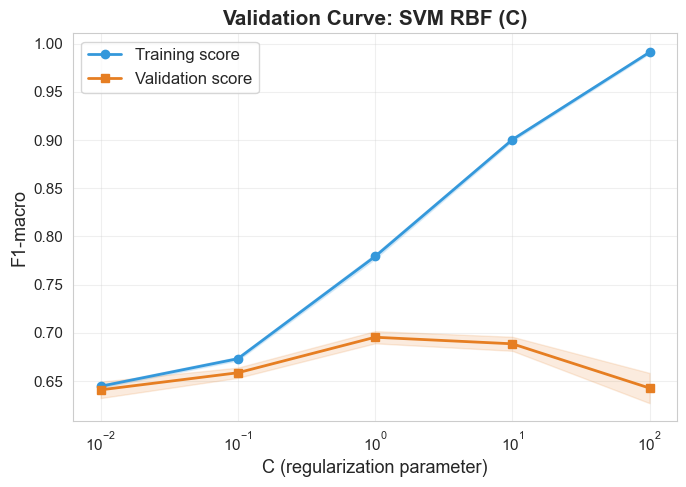

In [7]:
# SVM Validation Curve: C  large figure
svm_model = get_model("svm")
C_range = [0.01, 0.1, 1, 10, 100]
train_scores_svm, val_scores_svm = sklearn_valcurve(
    svm_model, X_trainval.values, y_trainval.values,
    param_name="C", param_range=C_range,
    scoring="f1_macro", cv=5, n_jobs=-1,
)

fig, ax = plt.subplots(figsize=(7, 5))
train_mean = train_scores_svm.mean(axis=1)
train_std = train_scores_svm.std(axis=1)
val_mean = val_scores_svm.mean(axis=1)
val_std = val_scores_svm.std(axis=1)

ax.plot(C_range, train_mean, "o-", color="#3498db", linewidth=2, label="Training score")
ax.fill_between(C_range, train_mean - train_std, train_mean + train_std, alpha=0.15, color="#3498db")
ax.plot(C_range, val_mean, "s-", color="#e67e22", linewidth=2, label="Validation score")
ax.fill_between(C_range, val_mean - val_std, val_mean + val_std, alpha=0.15, color="#e67e22")

ax.set_xscale("log")
ax.set_xlabel("C (regularization parameter)", fontsize=13)
ax.set_ylabel("F1-macro", fontsize=13)
ax.set_title("Validation Curve: SVM RBF (C)", fontsize=15, fontweight="bold")
ax.legend(fontsize=12)
ax.tick_params(labelsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "05_valcurve_svm_C_large.png"), dpi=200, bbox_inches="tight",
            facecolor="white")
print("Saved: data/plots/05_valcurve_svm_C_large.png")
plt.show()

Plot saved to E:\Project\2011machine_learning\data\plots\05_valcurve_svm_gamma.png


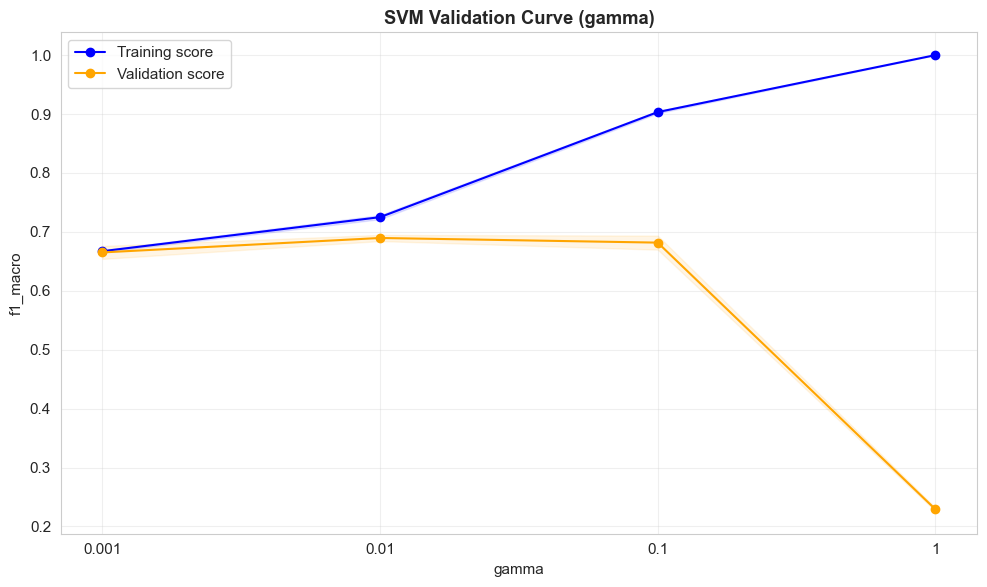

In [8]:
# SVM Validation Curve: gamma
fig = plot_validation_curve(
    get_model("svm"),
    X_trainval.values, y_trainval.values,
    param_name="gamma", param_range=[0.001, 0.01, 0.1, 1],
    title="SVM Validation Curve (gamma)", cv=5,
    save_path=os.path.join(PLOT_DIR, "05_valcurve_svm_gamma.png"),
)
plt.show()


### Validation Curve Analysis
**Decision Tree (max_depth)**:
- When max_depth is small, train/val scores are close but low → underfitting
- When max_depth increases, train score rises but val score drops → overfitting
- Optimal max_depth is where train-val gap is smallest and val score is highest

**Logistic Regression (C)**:
- Small C means strong regularization, model underfits
- As C increases, val score stabilizes
- LR is relatively insensitive to C, suggesting the linear assumption is the main bottleneck

**SVM (C and gamma)**:
- C controls regularization strength, gamma controls RBF kernel influence
- High gamma causes severe overfitting (each training point becomes its own support vector)
- Optimal combination requires tuning both parameters

## 5. Learning Curves
Learning curves show how training set size affects performance — helps determine if more data is needed.

Plot saved to E:\Project\2011machine_learning\data\plots\05_learning_curve_dt.png


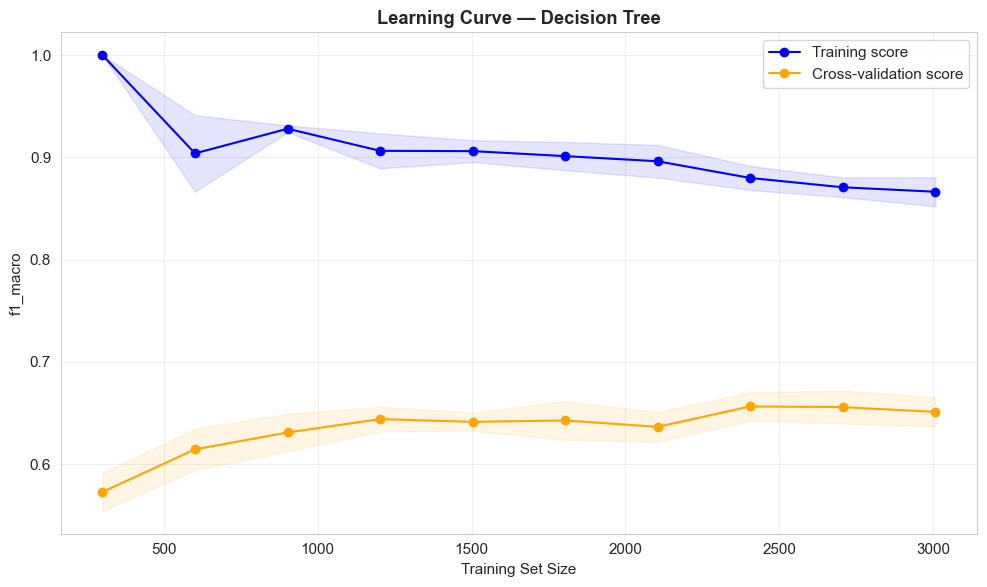

Plot saved to E:\Project\2011machine_learning\data\plots\05_learning_curve_lr.png


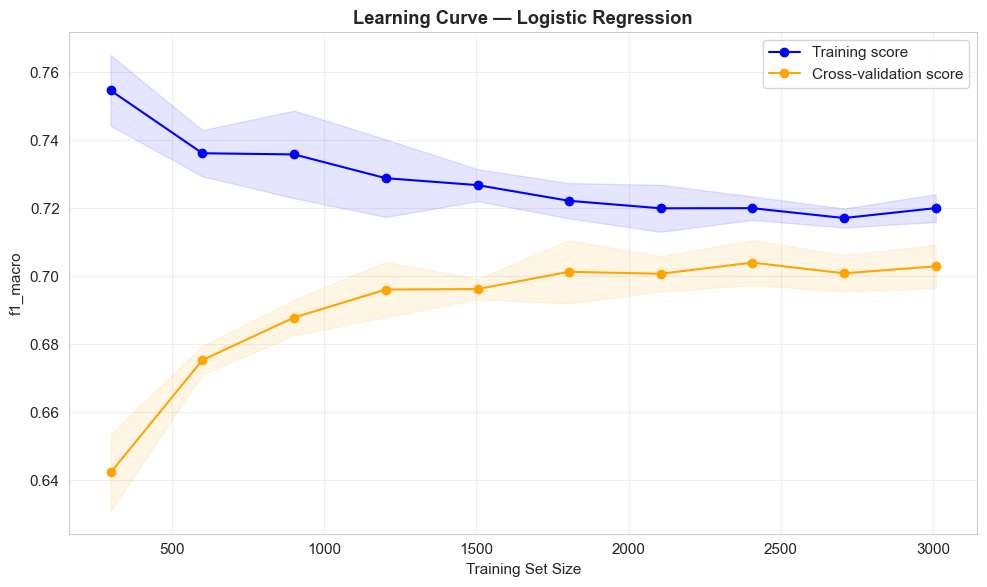

Plot saved to E:\Project\2011machine_learning\data\plots\05_learning_curve_svm.png


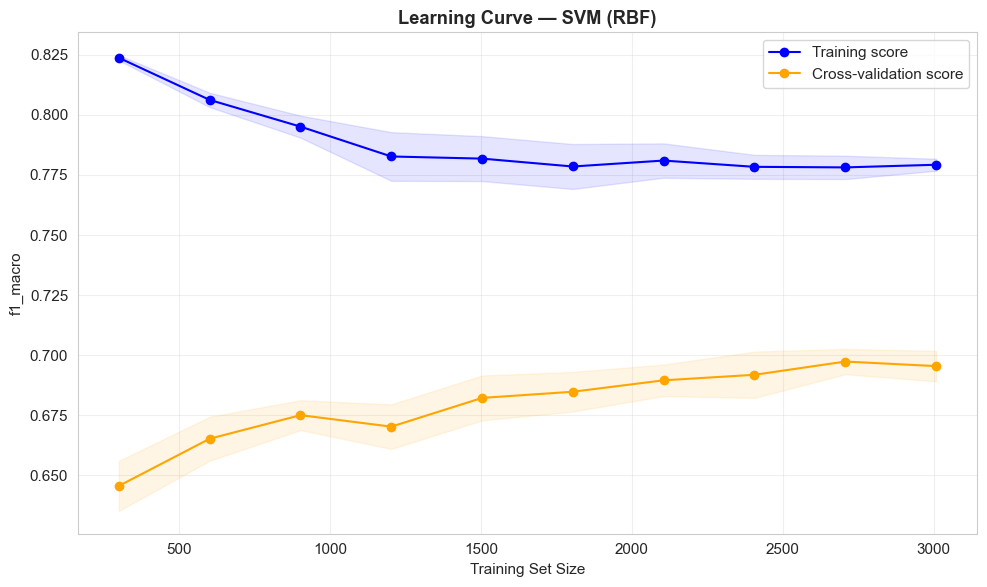

In [9]:
# Plot learning curve for each baseline model
for name, model_type in [
    ("Decision Tree", "dt"),
    ("Logistic Regression", "lr"),
    ("SVM (RBF)", "svm"),
]:
    model = get_model(model_type)
    plot_learning_curve(
        model, X_trainval.values, y_trainval.values,
        title=f"Learning Curve — {name}",
        save_path=os.path.join(PLOT_DIR, f"05_learning_curve_{model_type}.png"),
    )
    plt.show()


### Learning Curve Interpretation
- **Decision Tree**: Large gap between training and validation scores indicates overfitting. More data provides marginal improvement — the model complexity (even after tuning max_depth) captures noise.
- **Logistic Regression**: Training and validation scores converge, indicating good generalization. The model would benefit slightly from more data but is near its capacity given the linear assumption.
- **SVM (RBF)**: Moderate gap suggesting some overfitting. Validation score continues to rise with more data, suggesting the model could benefit from a larger training set.

## Model Tuning (GridSearchCV)
Based on validation curve analysis, we tune all three models via GridSearchCV.

In [10]:
#  Model Tuning via GridSearchCV
from src.evaluation import tune_model
from src.prediction import get_model

# Baselines match NB04 exactly; tuning search is isolated in param_grids
baseline_models = {
    "Decision Tree": get_model("dt"),
    "Logistic Regression": get_model("lr"),
    "SVM (RBF)": get_model("svm"),
}

param_grids = {
    "Decision Tree": {
        "max_depth": [3, 5, 8, 10, 15, 20],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "class_weight": ["balanced"],
    },
    "Logistic Regression": {
        "C": [0.01, 0.1, 1, 10, 100],
        "penalty": ["l1", "l2"],
        "solver": ["saga"],
        "max_iter": [50000],
        "class_weight": ["balanced"],
    },
    "SVM (RBF)": {
        "C": [0.1, 1, 10, 100],
        "gamma": ["scale", "auto", 0.01, 0.1],
        "class_weight": ["balanced"],
    },
}

tuned_results = {}
for name, base_model in baseline_models.items():
    print(f"{name}: ")
    result = tune_model(base_model, param_grids[name], X_trainval.values, y_trainval.values, cv=5)
    tuned_results[name] = result
    print(f"  Best params: {result['best_params']}")
    print(f"  Best CV F1(macro): {result['best_score']:.4f}")


Decision Tree: 


  Best params: {'class_weight': 'balanced', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
  Best CV F1(macro): 0.6839
Logistic Regression: 


E:\Project\2011machine_learning\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


  Best params: {'C': 10, 'class_weight': 'balanced', 'max_iter': 50000, 'penalty': 'l2', 'solver': 'saga'}
  Best CV F1(macro): 0.7051
SVM (RBF): 


  Best params: {'C': 10, 'class_weight': 'balanced', 'gamma': 0.01}
  Best CV F1(macro): 0.7039


In [11]:
# Baseline vs Tuned  / Performance comparison
from src.evaluation import calculate_metrics

comparison_rows = []
tuned_params_payload = {}
for name in baseline_models:
    base = baseline_models[name]
    base.fit(X_train.values, y_train.values)
    base_pred = base.predict(X_test.values)
    base_metrics = calculate_metrics(y_test.values, base_pred)

    tuned = tuned_results[name]["best_estimator"]
    tuned_pred = tuned.predict(X_test.values)
    tuned_metrics = calculate_metrics(y_test.values, tuned_pred)

    improvement = tuned_metrics["f1_macro"] - base_metrics["f1_macro"]
    comparison_rows.append({
        "model": name,
        "baseline_test_accuracy": float(base_metrics["accuracy"]),
        "baseline_test_f1_macro": float(base_metrics["f1_macro"]),
        "tuned_test_accuracy": float(tuned_metrics["accuracy"]),
        "tuned_test_f1_macro": float(tuned_metrics["f1_macro"]),
        "improvement_f1_macro": float(improvement),
        "best_cv_f1_macro": float(tuned_results[name]["best_score"]),
    })
    tuned_params_payload[name] = {
        "best_params": tuned_results[name]["best_params"],
        "best_cv_f1_macro": float(tuned_results[name]["best_score"]),
    }

comparison_df = pd.DataFrame(comparison_rows)
tuned_metrics_path = os.path.join(data_dir, "model_evaluation_tuned_metrics.csv")
comparison_df.to_csv(tuned_metrics_path, index=False)

params_path = os.path.join(data_dir, "model_evaluation_tuned_params.json")
with open(params_path, "w", encoding="utf-8") as f:
    json.dump(tuned_params_payload, f, indent=2)

print("Baseline vs Tuned Comparison:")
print(comparison_df.round(4).to_string(index=False))
print(f"\nSaved tuned metrics to {tuned_metrics_path}")
print(f"Saved tuned params to {params_path}")
comparison_df


Baseline vs Tuned Comparison:
              model  baseline_test_accuracy  baseline_test_f1_macro  tuned_test_accuracy  tuned_test_f1_macro  improvement_f1_macro  best_cv_f1_macro
      Decision Tree                  0.7123                  0.6752               0.6958               0.6731               -0.0021            0.6839
Logistic Regression                  0.7410                  0.7076               0.7410               0.7074               -0.0002            0.7051
          SVM (RBF)                  0.7319                  0.6955               0.7364               0.7033                0.0078            0.7039

Saved tuned metrics to E:\Project\2011machine_learning\data\model_evaluation_tuned_metrics.csv
Saved tuned params to E:\Project\2011machine_learning\data\model_evaluation_tuned_params.json


,model,baseline_test_accuracy,baseline_test_f1_macro,tuned_test_accuracy,tuned_test_f1_macro,improvement_f1_macro,best_cv_f1_macro
0,Decision Tree,0.712349,0.675230,0.695783,0.673096,-0.002134,0.683893
1,Logistic Regression,0.740964,0.707627,0.740964,0.707406,-0.000221,0.705119
2,SVM (RBF),0.731928,0.695472,0.736446,0.703314,0.007842,0.703899


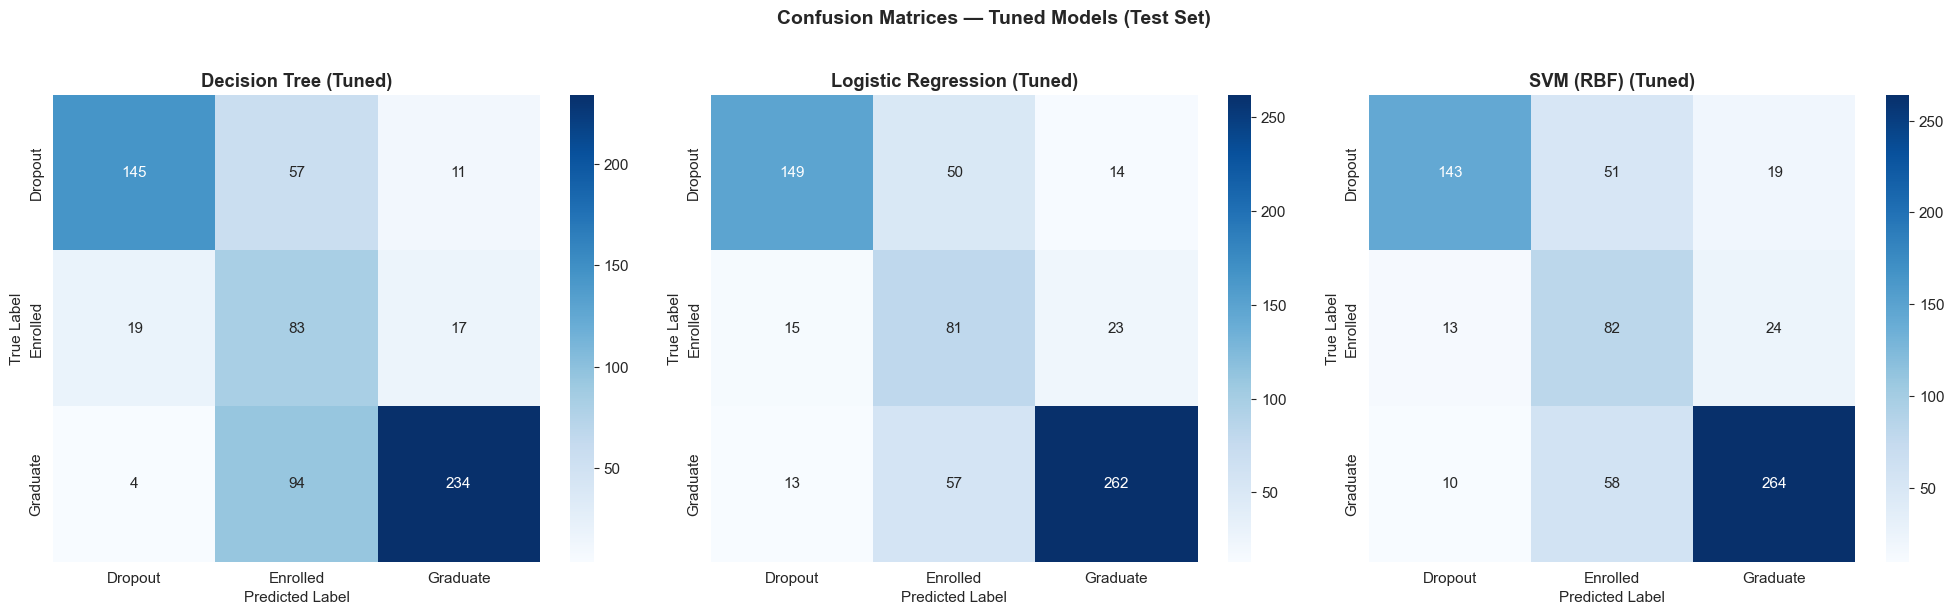

In [12]:
#  / Confusion matrices for tuned models
from src.prediction import plot_confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (name, result) in zip(axes, tuned_results.items()):
    tuned_model = result["best_estimator"]
    y_pred = tuned_model.predict(X_test.values)
    plot_confusion_matrix(y_test.values, y_pred, title=f"{name} (Tuned)", ax=ax)

plt.suptitle("Confusion Matrices — Tuned Models (Test Set)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "05_confusion_matrices_tuned.png"), dpi=150, bbox_inches="tight")
plt.show()


## Comprehensive Discussion
### Tuning Results Interpretation
- **Decision Tree**: Tuning constrains tree depth and leaf size to test whether reducing complexity can mitigate baseline overfitting.
- **Logistic Regression**: Tuning focuses on regularization strength and penalty type; if improvement is limited, the linear assumption itself is the main constraint.
- **SVM (RBF)**: Only tuning stage searches C and gamma; baseline SVM keeps NB04 default config to clearly distinguish default vs. tuned results.
### Overall Discussion
Based on accuracy, precision, recall, F1-score, ROC curves, AUC, cross-validation, validation curves, and learning curves, the three mandatory baseline models show different trade-offs. Decision Tree has the largest capacity and is most prone to overfitting, so its tuned result should be interpreted as a complexity-control experiment. Logistic Regression remains the most stable linear baseline when train/test and cross-validation evidence are considered together, although the linear boundary limits separation for the ambiguous Enrolled class. SVM with an RBF kernel provides a nonlinear baseline; its C and gamma search belongs to the tuned setting rather than the baseline setting. Across ROC/AUC and confusion-matrix evidence, Enrolled is expected to remain the hardest class because it lies between Dropout and Graduate outcomes. These results support baseline-stage model selection only; the overall final deployment choice is deferred to the open-ended ensemble comparison.